# 📈 Forex_DNN Historical Data Processing & Visualization Workbench

This interactive notebook is designed to run, test, and visually inspect the centralized historical data processing pipeline (`process_data.py`). It provides detailed step-by-step diagnostics, custom feature distributions, and beautiful pattern showcases for Smart Money Concepts (SMC), Supply/Demand Zones, and candle rejections.

### Key Features Included:
1. **Execution Modes**: 
   - `DEBUG`: Runs fast on a subset of data (e.g., last 1000 candles) and saves to a local debug folder without modifying production datasets.
   - `FULL`: Runs on all historical data of the selected symbol(s) and saves to standard production output directories.
2. **Feature Distributions**: Interactive/static histograms of indicators and candle scores.
3. **Pattern Showcase**: Automatically scans the dataset for the highest-scoring rejections or momentum candles and plots a zoomed-in candlestick view.
4. **Trend Sample Visualizer**: Extracts and displays multiple contiguous windows of candles matching requested trends (`bullish`, `bearish`, `range`).

In [1]:
import os
import sys

# Ensure we can import from the framework root
framework_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if framework_root not in sys.path:
    sys.path.append(framework_root)
print(f"Framework root added to sys.path: {framework_root}")

Framework root added to sys.path: C:\Users\MHossein\Documents\GitHub\Forex_DNN


In [2]:
import argparse
import logging
import json
import yaml
import time
import threading
import multiprocessing
import shutil
from datetime import datetime, timezone
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Tuple, Optional
import concurrent.futures
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from Configs.path_manager import PathManager
from ML.feature_registry import FeatureRegistry
from ML.feature_pipeline import FeaturePipeline
from ML.data_cleaner import DataCleaner
from ML.dataset_validator import DatasetValidator
from ML.label_engine import LabelEngine
from ML.market_state_labeler import MarketStateLabeler
from ML.dataset_builder import DatasetBuilder
from ML.checkpoint_manager import CheckpointManager

from Market_Data_Pipeline.historical_dataset_builder import HistoricalDatasetBuilder
from Market_Data_Pipeline.structure_engine import MarketStructureEngine
from Market_Data_Pipeline.supply_demand_engine import SupplyDemandEngine
from Market_Data_Pipeline.strong_candle_engine import StrongCandleEngine
from Market_Data_Pipeline.refusal_candle_engine import RefusalCandleEngine
from Market_Data_Pipeline.structure_graph import MarketStructureGraph
from Collecting_Data.indicators import IndicatorEngine
from Visualization.chart_annotator import ChartAnnotationEngine
from Visualization.debug_config import DebugConfig

In [4]:
# Configure Notebook Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger("NotebookProcessPipeline")

class ProcessingProgressMonitor:
    """
    Thread-safe console progress visualizer for the data processing pipeline.
    """
    def __init__(self, num_workers: int, total_symbols: int, enabled: bool = True):
        self.num_workers = num_workers
        self.total_symbols = total_symbols
        self.completed_symbols = 0
        self.start_time = time.time()
        self.enabled = enabled
        self.lock = threading.Lock()
        self.slots = {i: {"symbol": "-", "phase": "Idle", "pct": 0, "status": "Idle", "thread_id": None} for i in range(1, num_workers + 1)}

    def register_worker(self, thread_id) -> int:
        with self.lock:
            for slot, info in self.slots.items():
                if info.get("thread_id") == thread_id:
                    return slot
            for slot, info in self.slots.items():
                if info.get("thread_id") is None:
                    self.slots[slot]["thread_id"] = thread_id
                    return slot
            return 1

    def register_symbol_slot(self, symbol: str) -> int:
        with self.lock:
            for slot, info in self.slots.items():
                if info.get("symbol") == symbol:
                    return slot
            for slot, info in self.slots.items():
                if info.get("symbol") == "-" or info.get("symbol") is None:
                    self.slots[slot]["symbol"] = symbol
                    return slot
            return 1

    def release_symbol_slot(self, symbol: str):
        with self.lock:
            for slot, info in self.slots.items():
                if info.get("symbol") == symbol:
                    self.slots[slot] = {"symbol": "-", "phase": "Idle", "pct": 0, "status": "Idle", "thread_id": None}
                    break

    def increment_completed(self):
        with self.lock:
            self.completed_symbols += 1
            print(f"[PROGRESS] {self.completed_symbols}/{self.total_symbols} symbols completed.")

    def update(self, slot_id: int, symbol: str, phase: str, pct: int, status: str):
        if not self.enabled:
            return
        with self.lock:
            self.slots[slot_id].update({
                "symbol": symbol,
                "phase": phase,
                "pct": pct,
                "status": status
            })
            # Notebook simple print to avoid breaking cell lines with ANSI escape chars
            if pct % 20 == 0 or pct == 100:
                print(f"  [{symbol}] {phase} -> {pct}% ({status})")

In [5]:
def load_config(config_path: str) -> Dict[str, Any]:
    defaults = {
        "input_dir": PathManager.get_relative_path("historical_data"),
        "output_dir": PathManager.get_relative_path("datasets"),
        "timeframe": "M5",
        "window_size": 35,
        "window_stride": 1,
        "max_workers": 1,
        "use_multiprocessing": False,
        "clean_data": True,
        "drop_duplicates": True,
        "handle_missing": True
    }
    if os.path.exists(config_path):
        try:
            with open(config_path, "r") as f:
                cfg = yaml.safe_load(f)
                if isinstance(cfg, dict):
                    defaults.update(cfg)
                    print(f"Loaded configuration from {config_path}")
        except Exception as e:
            print(f"Failed to parse config file '{config_path}': {e}. Using defaults.")
    else:
        print(f"Config file not found: {config_path}. Using defaults.")
    return defaults

def discover_historical_files(input_dir: str, symbol_filter: str, timeframe: str) -> Dict[str, str]:
    discovered = {}
    if not os.path.exists(input_dir):
        return discovered

    for item in os.listdir(input_dir):
        subdir = os.path.join(input_dir, item)
        if os.path.isdir(subdir):
            p_path = os.path.join(subdir, f"{timeframe}.parquet")
            if os.path.exists(p_path):
                discovered[item.upper()] = p_path
                continue
            c_path = os.path.join(subdir, f"{timeframe}.csv")
            if os.path.exists(c_path):
                discovered[item.upper()] = c_path
                continue

    for file in os.listdir(input_dir):
        file_path = os.path.join(input_dir, file)
        if os.path.isfile(file_path):
            import re
            match = re.match(r"^([A-Z0-9#_.]+)_" + re.escape(timeframe) + r"\.(parquet|csv)$", file, re.IGNORECASE)
            if match:
                sym = match.group(1).upper()
                if sym not in discovered:
                    discovered[sym] = file_path

    if symbol_filter.upper() != "ALL":
        target_symbols = [s.strip().upper() for s in symbol_filter.split(",")]
        filtered = {}
        for sym in target_symbols:
            if sym in discovered:
                filtered[sym] = discovered[sym]
            else:
                print(f"Requested symbol '{sym}' was not discovered in raw folder '{input_dir}'!")
        discovered = filtered

    return discovered

def clean_raw_candles(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    mapping = {
        "datetime": "Datetime", "date_time": "Datetime", "timestamp": "Datetime",
        "close": "Close", "open": "Open", "high": "High", "low": "Low",
        "tick_volume": "TickVolume", "volume": "TickVolume", "spread": "Spread"
    }
    for col in df_clean.columns:
        if col.lower() in mapping:
            df_clean.rename(columns={col: mapping[col.lower()]}, inplace=True)

    essential = ["Datetime", "Open", "High", "Low", "Close"]
    for col in essential:
        if col not in df_clean.columns:
            if col == "Datetime":
                df_clean["Datetime"] = pd.date_range("2024-01-01", periods=len(df_clean), freq="5min")
            else:
                df_clean[col] = 1.1000

    df_clean.dropna(subset=["Datetime", "Close"], inplace=True)
    df_clean["Datetime"] = pd.to_datetime(df_clean["Datetime"])
    df_clean.drop_duplicates(subset=["Datetime"], keep="first", inplace=True)
    df_clean.sort_values(by="Datetime", inplace=True)
    df_clean.reset_index(drop=True, inplace=True)

    if "TickVolume" not in df_clean.columns:
        df_clean["TickVolume"] = 100.0
    if "Spread" not in df_clean.columns:
        df_clean["Spread"] = 1.0

    return df_clean

def save_parquet_atomically(df: pd.DataFrame, path: str) -> None:
    temp_path = f"{path}.tmp"
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    df.to_parquet(temp_path, index=False)
    os.replace(temp_path, path)

In [6]:
def process_single_symbol(
    symbol: str,
    file_path: str,
    cfg: Dict[str, Any],
    registry: FeatureRegistry,
    cache_dir: str = None,
    monitor: Optional[ProcessingProgressMonitor] = None,
    slot_id: Optional[int] = None,
    progress_queue: Optional[Any] = None
) -> Tuple[Optional[str], Optional[str]]:
    """
    Loads, cleans, enriches, and produces Market State and Level Break datasets for a single symbol
    utilizing robust stage-by-stage checkpointing and automatic resume.
    """
    try:
        if monitor and slot_id is None:
            slot_id = monitor.register_worker(threading.get_ident())

        def update_progress(phase: str, pct: int, status: str, log_msg: Optional[str] = None):
            if progress_queue is not None:
                progress_queue.put(("UPDATE", symbol, phase, pct, status, log_msg))
            elif monitor and slot_id:
                monitor.update(slot_id, symbol, phase, pct, status)
            elif log_msg:
                logger.info(log_msg)

        # Setup Stage Directories and Checkpoint Manager
        stages_dir = PathManager.get_path("temporary", "stages")
        checkpoint_dir = PathManager.get_path("temporary", "checkpoints")
        stages = ["CLEAN", "ENRICH", "EVAL", "STATE", "LEVEL"]

        cp_mgr = CheckpointManager(
            symbol=symbol,
            timeframe=cfg["timeframe"],
            window_size=cfg["window_size"],
            stages=stages,
            checkpoint_dir=checkpoint_dir
        )

        while True:
            next_stage = cp_mgr.get_next_unfinished_stage()
            if next_stage is None:
                break

            # ----------------- STAGE 1: CLEAN -----------------
            if next_stage == "CLEAN":
                cp_mgr.mark_stage_started("CLEAN")
                update_progress("CLEANING", 0, "Loading & cleaning raw candles...", f"[{symbol}] [Stage CLEAN] Loading raw candles...")

                if file_path.endswith(".parquet"):
                    df_raw = pd.read_parquet(file_path)
                else:
                    df_raw = pd.read_csv(file_path)

                # Apply DEBUG mode max candles if requested
                if cfg.get("debug_max_candles") is not None:
                    df_raw = df_raw.iloc[-cfg["debug_max_candles"]:].copy()
                    logger.info(f"[{symbol}] DEBUG mode: sliced raw candles to last {len(df_raw)} rows.")

                df_clean = clean_raw_candles(df_raw)
                total_bars = len(df_clean)

                if total_bars < cfg["window_size"]:
                    raise ValueError(f"Insufficient candles ({total_bars}) for window size {cfg['window_size']}.")

                clean_out_path = os.path.join(stages_dir, f"{symbol}_clean.parquet")
                save_parquet_atomically(df_clean, clean_out_path)
                cp_mgr.mark_stage_completed("CLEAN", clean_out_path)
                del df_raw, df_clean
                import gc
                gc.collect()
                update_progress("CLEANING", 100, f"Cleaned {total_bars} bars")

            # ----------------- STAGE 2: ENRICH -----------------
            elif next_stage == "ENRICH":
                cp_mgr.mark_stage_started("ENRICH")
                update_progress("PROCESSING", 0, "Computing EMAs & SMC structures...", f"[{symbol}] [Stage ENRICH] Computing SMC...")

                clean_in_path = cp_mgr.get_stage_output("CLEAN")
                df_clean = pd.read_parquet(clean_in_path)

                ind_engine = IndicatorEngine(ema_periods=[50, 600, 800], slope_period=32)
                df_enriched = ind_engine.calculate(df_clean)

                ms_engine = MarketStructureEngine(lookback=3)
                df_enriched = ms_engine.process(df_enriched)

                sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
                df_enriched = sd_engine.process(df_enriched)

                enrich_out_path = os.path.join(stages_dir, f"{symbol}_enriched.parquet")
                save_parquet_atomically(df_enriched, enrich_out_path)
                cp_mgr.mark_stage_completed("ENRICH", enrich_out_path)
                del df_clean, df_enriched
                import gc
                gc.collect()
                update_progress("PROCESSING", 100, "Completed structures")

            # ----------------- STAGE 3: EVAL -----------------
            elif next_stage == "EVAL":
                cp_mgr.mark_stage_started("EVAL")
                update_progress("CANDLE_EVAL", 0, "Evaluating candles...", f"[{symbol}] [Stage EVAL] Running candle evaluations...")

                enrich_in_path = cp_mgr.get_stage_output("ENRICH")
                df_enriched = pd.read_parquet(enrich_in_path)
                total_bars = len(df_enriched)

                ms_engine = MarketStructureEngine(lookback=3)
                df_struct = ms_engine.process(df_enriched)
                sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
                df_final_struct = sd_engine.process(df_struct)

                msg = MarketStructureGraph(
                    symbol=symbol,
                    timeframe=cfg["timeframe"],
                    swing_highs=[s for s in ms_engine.swings if s.level_type == "SwingHigh"],
                    swing_lows=[s for s in ms_engine.swings if s.level_type == "SwingLow"],
                    protected_high=ms_engine.protected_high,
                    protected_low=ms_engine.protected_low,
                    bos=list(ms_engine.bos_list),
                    choch=list(ms_engine.choch_list),
                    supply_zones=[z for z in sd_engine.zones if z.type == "Supply"],
                    demand_zones=[z for z in sd_engine.zones if z.type == "Demand"],
                    trend_direction="Bull" if df_final_struct.iloc[-1].get("trend", 0) == 1 else ("Bear" if df_final_struct.iloc[-1].get("trend", 0) == -1 else "Neutral"),
                    atr=float(df_final_struct.iloc[-1].get("atr_14", 0.0001))
                )

                strong_eng = StrongCandleEngine()
                refusal_eng = RefusalCandleEngine()

                strong_scores = []
                strong_confs = []
                refusal_scores = []
                refusal_confs = []

                log_interval = max(1, total_bars // 10)
                for i in range(total_bars):
                    sc = strong_eng.evaluate(df_final_struct, i, msg)
                    rc = refusal_eng.evaluate_rejection(df_final_struct, i, None, msg)
                    strong_scores.append(sc.quality_score)
                    strong_confs.append(sc.confidence)
                    refusal_scores.append(rc.quality_score)
                    refusal_confs.append(rc.confidence)

                    if (i + 1) % log_interval == 0 or i == total_bars - 1:
                        pct = int((i + 1) / total_bars * 100)
                        update_progress("CANDLE_EVAL", pct, f"Bars {i+1}/{total_bars}")

                df_evaluated = df_enriched.copy()
                df_evaluated["strong_candle_score"] = strong_scores
                df_evaluated["strong_candle_confidence"] = strong_confs
                df_evaluated["refusal_candle_score"] = refusal_scores
                df_evaluated["refusal_candle_confidence"] = refusal_confs

                eval_out_path = os.path.join(stages_dir, f"{symbol}_evaluated.parquet")
                save_parquet_atomically(df_evaluated, eval_out_path)
                cp_mgr.mark_stage_completed("EVAL", eval_out_path)
                del df_enriched, df_evaluated, df_struct, df_final_struct, msg
                import gc
                gc.collect()
                update_progress("CANDLE_EVAL", 100, "Completed candle evaluations")

            # ----------------- STAGE 4: STATE -----------------
            elif next_stage == "STATE":
                cp_mgr.mark_stage_started("STATE")
                update_progress("LABELING_MS", 0, "Starting Market State labeling...")

                eval_in_path = cp_mgr.get_stage_output("EVAL")
                df_evaluated = pd.read_parquet(eval_in_path)

                ms_engine = MarketStructureEngine(lookback=3)
                df_struct = ms_engine.process(df_evaluated)
                sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
                df_final_struct = sd_engine.process(df_struct)

                label_engine = LabelEngine(
                    window_size=cfg["window_size"],
                    window_stride=cfg["window_stride"],
                    registry=registry
                )
                # Simple wrapper around generate_dataset to print updates
                df_state = label_engine.generate_dataset(
                    data_inputs={(symbol, cfg["timeframe"]): df_final_struct},
                    ms_engine=ms_engine,
                    sd_engine=sd_engine,
                    monitor=None,
                    slot_id=None
                )

                state_out_path = os.path.join(stages_dir, f"{symbol}_state.parquet")
                save_parquet_atomically(df_state, state_out_path)
                cp_mgr.mark_stage_completed("STATE", state_out_path)
                del df_evaluated, df_struct, df_final_struct, df_state, label_engine
                import gc
                gc.collect()
                update_progress("LABELING_MS", 100, "Completed market state labeling")

            # ----------------- STAGE 5: LEVEL -----------------
            elif next_stage == "LEVEL":
                cp_mgr.mark_stage_started("LEVEL")
                update_progress("LABELING_LVL", 0, "Starting Level Break labeling...")

                eval_in_path = cp_mgr.get_stage_output("EVAL")
                df_evaluated = pd.read_parquet(eval_in_path)

                ms_engine = MarketStructureEngine(lookback=3)
                df_struct = ms_engine.process(df_evaluated)
                sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
                df_final_struct = sd_engine.process(df_struct)

                msg = MarketStructureGraph(
                    symbol=symbol,
                    timeframe=cfg["timeframe"],
                    swing_highs=[s for s in ms_engine.swings if s.level_type == "SwingHigh"],
                    swing_lows=[s for s in ms_engine.swings if s.level_type == "SwingLow"],
                    protected_high=ms_engine.protected_high,
                    protected_low=ms_engine.protected_low,
                    bos=list(ms_engine.bos_list),
                    choch=list(ms_engine.choch_list),
                    supply_zones=[z for z in sd_engine.zones if z.type == "Supply"],
                    demand_zones=[z for z in sd_engine.zones if z.type == "Demand"],
                    trend_direction="Bull" if df_final_struct.iloc[-1].get("trend", 0) == 1 else ("Bear" if df_final_struct.iloc[-1].get("trend", 0) == -1 else "Neutral"),
                    atr=float(df_final_struct.iloc[-1].get("atr_14", 0.0001))
                )

                db_builder = DatasetBuilder(registry=registry)
                df_level = db_builder.build_level_break_dataset(
                    df_final_struct, msg,
                    monitor=None,
                    slot_id=None
                )
                if not df_level.empty:
                    df_level["symbol"] = symbol
                    df_level["timeframe"] = cfg["timeframe"]

                level_out_path = os.path.join(stages_dir, f"{symbol}_level.parquet")
                save_parquet_atomically(df_level, level_out_path)
                cp_mgr.mark_stage_completed("LEVEL", level_out_path)
                del df_evaluated, df_struct, df_final_struct, msg, df_level, db_builder
                import gc
                gc.collect()
                update_progress("LABELING_LVL", 100, "Completed level break labeling")

        state_final_path = cp_mgr.get_stage_output("STATE")
        level_final_path = cp_mgr.get_stage_output("LEVEL")
        return state_final_path, level_final_path

    except Exception as e:
        logger.error(f"[{symbol}] Error processing symbol: {e}", exc_info=True)
        return None, None

## ⚙️ 2. CONFIGURATION & RUNTIME EXECUTION

Configure execution modes and run the pipeline here. 
- **DEBUG mode** runs on the last 1000 candles to process in under a few seconds and saves outputs locally.
- **FULL mode** processes all historical files found inside `Data/Historical`.

In [7]:
# =====================================================================
# CONFIGURATION PARAMETERS
# =====================================================================
MODE = "DEBUG"            # Choose "DEBUG" or "FULL"
SYMBOL = "XAUUSD_o"         # Specific symbol, e.g. "EURUSD", "GBPUSD", or "ALL" to process all
TIMEFRAME = "M5"          # Timeframe (e.g. "M5", "M15", etc.)
FORCE_CLEAN = True        # Clear checkpoints and stage cache before running

# In DEBUG mode, slice raw candles to this limit (faster processing)
DEBUG_MAX_CANDLES = 100000 

In [8]:
# Create directories
stages_dir = PathManager.get_path("temporary", "stages")
checkpoint_dir = PathManager.get_path("temporary", "checkpoints")

if FORCE_CLEAN:
    print("Clearing temporary stages, checkpoints, and cache directories...")
    shutil.rmtree(stages_dir, ignore_errors=True)
    shutil.rmtree(checkpoint_dir, ignore_errors=True)
    shutil.rmtree(PathManager.get_path("cache"), ignore_errors=True)

os.makedirs(stages_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

# Discover historical files
input_dir = PathManager.get_relative_path("historical_data")
discovered = discover_historical_files(input_dir, SYMBOL, TIMEFRAME)

if not discovered:
    print(f"\n\033[91m\033[1m[WARNING] No historical data files discovered for SYMBOL '{SYMBOL}' in '{input_dir}'!\033[0m")
    print("Please download historical data first using the command line:")
    print("   python Collecting_Data/historical_data_collector.py --symbols EURUSD --timeframe M5")
    print(f"Or verify if data exists in: {PathManager.get_path('historical_data')}\n")
else:
    print(f"\n[INFO] Discovered {len(discovered)} symbol(s) to process: {list(discovered.keys())}")
    
    # Set up config dictionary
    cfg = {
        "input_dir": input_dir,
        "output_dir": PathManager.get_relative_path("datasets") if MODE == "FULL" else os.path.join(stages_dir, "debug_datasets"),
        "timeframe": TIMEFRAME,
        "window_size": 500,
        "window_stride": 1,
        "max_workers": 1,
        "use_multiprocessing": False,
        "clean_data": True,
        "drop_duplicates": True,
        "handle_missing": True,
        "debug_max_candles": DEBUG_MAX_CANDLES if MODE == "DEBUG" else None
    }
    
    registry = FeatureRegistry(load_defaults=True)
    monitor = ProcessingProgressMonitor(num_workers=1, total_symbols=len(discovered))
    
    print(f"Executing pipeline in {MODE} mode sequentially...")
    processed_symbols_data = {}
    
    for sym, filepath in discovered.items():
        state_path, level_path = process_single_symbol(
            symbol=sym,
            file_path=filepath,
            cfg=cfg,
            registry=registry,
            cache_dir=None,
            monitor=monitor,
            slot_id=1
        )
        
        if state_path:
            # Load processed evaluated parquet file (which is the input to Stage 4 STATE/Stage 5 LEVEL)
            eval_path = os.path.join(stages_dir, f"{sym}_evaluated.parquet")
            if os.path.exists(eval_path):
                df_eval = pd.read_parquet(eval_path)
                processed_symbols_data[sym] = df_eval
                print(f"[SUCCESS] Symbol '{sym}' processed successfully. Sample count: {len(df_eval)}")
            else:
                print(f"[WARNING] Evaluated stage file not found at {eval_path}")
        else:
            print(f"[FAIL] Failed to process symbol '{sym}'. Check logs.")
        monitor.increment_completed()

Clearing temporary stages, checkpoints, and cache directories...

[INFO] Discovered 1 symbol(s) to process: ['XAUUSD_O']
Executing pipeline in DEBUG mode sequentially...
2026-07-30 06:45:37,932 [INFO] CheckpointManager: [XAUUSD_O] No valid checkpoint found. Initializing fresh processing state.
2026-07-30 06:45:37,946 [INFO] CheckpointManager: [XAUUSD_O] Transitioning state: Stage 'CLEAN' started.
  [XAUUSD_O] CLEANING -> 0% (Loading & cleaning raw candles...)
2026-07-30 06:45:39,043 [INFO] NotebookProcessPipeline: [XAUUSD_O] DEBUG mode: sliced raw candles to last 100000 rows.
2026-07-30 06:45:39,367 [INFO] CheckpointManager: [XAUUSD_O] Transitioning state: Stage 'CLEAN' successfully completed.
  [XAUUSD_O] CLEANING -> 100% (Cleaned 100000 bars)
2026-07-30 06:45:39,459 [INFO] CheckpointManager: [XAUUSD_O] Transitioning state: Stage 'ENRICH' started.
  [XAUUSD_O] PROCESSING -> 0% (Computing EMAs & SMC structures...)
2026-07-30 06:46:39,007 [INFO] CheckpointManager: [XAUUSD_O] Transitioni

## 📊 3. DIAGNOSTICS & VERIFICATION VISUALIZATIONS

This section provides interactive tools to check features and trends to ensure correctness.

In [9]:
def plot_candlesticks(ax, df_slice: pd.DataFrame):
    """
    Draws high-quality candlesticks on a matplotlib axis using absolute index positions.
    """
    for idx, row in df_slice.iterrows():
        open_val = row["Open"]
        high_val = row["High"]
        low_val = row["Low"]
        close_val = row["Close"]
        
        is_bullish = close_val >= open_val
        color = "green" if is_bullish else "red"
        
        # Wick (low to high)
        ax.vlines(idx, low_val, high_val, color=color, linewidth=1, alpha=0.8)
        
        # Body (open to close box)
        body_bottom = min(open_val, close_val)
        body_height = max(abs(close_val - open_val), 1e-6)
        rect = plt.Rectangle((idx - 0.35, body_bottom), 0.7, body_height, facecolor=color, edgecolor=color, alpha=0.8)
        ax.add_patch(rect)

def show_feature_definitions():
    """
    Prints an elegant markdown summary table explaining core feature definitions.
    """
    from IPython.display import display, Markdown
    
    table = """
| Feature Group | Feature Name | Description | Calculation / Detection Rule |
| :--- | :--- | :--- | :--- |
| **Trend / Regime** | `trend` | Current market structure direction | `1` = Bullish, `-1` = Bearish, `0` = Neutral/Range |
| **Candle Rejection** | `refusal_candle_score` | Rejection strength at support/resistance | Multi-factor wick/tail size scoring from `[0, 100]` |
| **Candle Rejection** | `refusal_candle_confidence` | Normalized confidence of rejection | Confidence rating from `[0.0, 1.0]` |
| **Candle Momentum** | `strong_candle_score` | Trend momentum / expansion strength | Normalized breakout size scoring from `[0, 100]` |
| **Candle Momentum** | `strong_candle_confidence` | Normalized confidence of strong candle | Confidence rating from `[0.0, 1.0]` |
| **Structure** | `swing_highs` / `swing_lows` | Key pivots / structural high/low | Pivot points detected using exact SmartMoneyConcepts lookbacks |
| **Structure** | `bos` / `choch` | Structure Breakout / Change of Character | Breakout of previous-pivot high/low level with body confirmation |
| **S&D Zones** | `supply_zones` / `demand_zones` | Supply and Demand zones (Order Blocks) | Created on BOS/CHOCH structure breaks, tracked sequentially |
"""
    display(Markdown("### 📚 Processed Features & Analytical Definitions"))
    display(Markdown(table))

def show_feature_distributions(df: pd.DataFrame, selected_features: list = None):
    """
    Visualizes the histogram and density distributions of requested features.
    """
    if df is None or df.empty:
        print("DataFrame is empty. Cannot plot distributions.")
        return
        
    if selected_features is None:
        selected_features = [
            "strong_candle_score", "strong_candle_confidence",
            "refusal_candle_score", "refusal_candle_confidence",
            "trend"
        ]
        
    features_to_plot = [f for f in selected_features if f in df.columns]
    if not features_to_plot:
        print(f"None of the requested features {selected_features} exist in the processed dataset.")
        return
        
    num_cols = min(3, len(features_to_plot))
    num_rows = (len(features_to_plot) + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    if num_rows == 1 and num_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(features_to_plot):
        ax = axes[idx]
        sns.histplot(df[col].dropna(), ax=ax, kde=True, color="skyblue")
        ax.set_title(f"Distribution of '{col}'")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.grid(True, linestyle=":", alpha=0.5)
        
    for idx in range(len(features_to_plot), len(axes)):
        fig.delaxes(axes[idx])
        
    plt.tight_layout()
    plt.show()

def visualize_feature_sample(df: pd.DataFrame, feature_name: str, symbol: str, timeframe: str, window_size: int = 35):
    """
    Finds the highest quality sample event for a given feature and plots a zoomed-in candlestick chart.
    """
    if df is None or df.empty:
        print("DataFrame is empty. Run the pipeline first.")
        return
        
    target_col = None
    if feature_name.lower() in ["refusal_candle", "refusal"]:
        target_col = "refusal_candle_score"
    elif feature_name.lower() in ["strong_candle", "strong"]:
        target_col = "strong_candle_score"
    else:
        print(f"Unknown feature_name '{feature_name}'. Supported: 'refusal_candle', 'strong_candle'")
        return
        
    if target_col not in df.columns:
        print(f"Column '{target_col}' not found in DataFrame.")
        return
        
    max_idx = df[target_col].idxmax()
    score_val = df.loc[max_idx, target_col]
    conf_val = df.loc[max_idx, target_col.replace("score", "confidence")]
    
    print(f"Highest quality '{feature_name}' found at index {max_idx} with score {score_val} and confidence {conf_val:.2f}.")
    
    start_idx = max(0, max_idx - window_size // 2)
    end_idx = min(len(df) - 1, start_idx + window_size)
    
    if end_idx == len(df) - 1:
        start_idx = max(0, end_idx - window_size)
        
    df_slice = df.iloc[start_idx:end_idx + 1].copy()
    
    ms_engine = MarketStructureEngine(lookback=3)
    df_struct = ms_engine.process(df)
    sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
    df_final = sd_engine.process(df_struct)
    
    msg = MarketStructureGraph(
        symbol=symbol,
        timeframe=timeframe,
        swing_highs=[s for s in ms_engine.swings if s.level_type == "SwingHigh"],
        swing_lows=[s for s in ms_engine.swings if s.level_type == "SwingLow"],
        protected_high=ms_engine.protected_high,
        protected_low=ms_engine.protected_low,
        bos=list(ms_engine.bos_list),
        choch=list(ms_engine.choch_list),
        supply_zones=[z for z in sd_engine.zones if z.type == "Supply"],
        demand_zones=[z for z in sd_engine.zones if z.type == "Demand"],
        trend_direction="Bull" if df_final.iloc[-1].get("trend", 0) == 1 else ("Bear" if df_final.iloc[-1].get("trend", 0) == -1 else "Neutral"),
        atr=float(df_final.iloc[-1].get("atr_14", 0.0001))
    )
    
    fig, ax = plt.subplots(figsize=(15, 7))
    plot_candlesticks(ax, df_slice)
    
    # Highlight specific candle
    ax.axvline(x=max_idx, color="magenta", linestyle=":", alpha=0.7, label=f"Selected {feature_name} sample")
    
    for ema_col, color, lbl in [("ema_50", "orange", "EMA 50"), ("ema_600", "purple", "EMA 600"), ("ema_800", "brown", "EMA 800")]:
        if ema_col in df_slice.columns:
            ax.plot(df_slice.index, df_slice[ema_col], color=color, label=lbl, alpha=0.5)
            
    config = DebugConfig()
    config.set_layer("swings", True)
    config.set_layer("structure", True)
    config.set_layer("zones", True)
    annotator = ChartAnnotationEngine(config=config)
    
    annotator.annotate_matplotlib(ax=ax, msg=msg, df=df)
    
    ax.set_xlim(start_idx, end_idx)
    y_min = df_slice["Low"].min() - msg.atr * 2
    y_max = df_slice["High"].max() + msg.atr * 2
    ax.set_ylim(y_min, y_max)
    
    ax.set_title(f"[{symbol}] Pattern Showcase: '{feature_name}' Highest Quality Sample (Index {max_idx} | Score {score_val})", fontsize=14, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper left")
    
    datetimes = df_slice["Datetime"].dt.strftime("%m-%d %H:%M").tolist()
    tick_step = max(1, len(df_slice) // 6)
    tick_positions = list(range(start_idx, end_idx + 1, tick_step))
    tick_labels = [datetimes[i - start_idx] for i in tick_positions if (i - start_idx) < len(datetimes)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=15, fontsize=8)
    
    plt.tight_layout()
    plt.show()

def visualize_trend(
    df: pd.DataFrame,
    trend_type: str,
    symbol: str,
    timeframe: str,
    num_charts: int = 3,
    index: Optional[int] = None,
    window_size: int = 35,
    show_smc: bool = True,
    show_zones: bool = True,
    show_ref_and_strong: bool = True
):
    """
    Finds and plots windows of candles matching a specific trend state.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    trend_map = {
        "bullish": 1,
        "bearish": -1,
        "range": 0
    }
    
    target_trend = trend_map.get(trend_type.lower())
    if target_trend is None:
        print(f"Invalid trend_type '{trend_type}'. Must be one of: 'bullish', 'bearish', 'range'")
        return

    matching_indices = df[df["trend"] == target_trend].index.tolist()
    if not matching_indices:
        print(f"No matching windows found for trend: {trend_type}")
        return

    segments = []
    if matching_indices:
        current_segment = [matching_indices[0]]
        for idx in matching_indices[1:]:
            if idx == current_segment[-1] + 1:
                current_segment.append(idx)
            else:
                segments.append(current_segment)
                current_segment = [idx]
        segments.append(current_segment)

    print(f"Discovered {len(segments)} distinct continuous {trend_type} trend segments.")

    if index is not None:
        if index < 0 or index >= len(segments):
            print(f"Invalid segment index {index}. Must be between 0 and {len(segments)-1}.")
            return
        segments_to_plot = [segments[index]]
        segment_indices_to_label = [index]
    else:
        if num_charts >= 10:
            print("\033[93m\033[1m[WARNING] Producing 10 or more charts may slow down the notebook or consume substantial memory. Consider choosing num_charts < 10 or using the index parameter to inspect a specific window.\033[0m")
        segments_to_plot = segments[:num_charts]
        segment_indices_to_label = list(range(len(segments_to_plot)))

    ms_engine = MarketStructureEngine(lookback=3)
    df_struct = ms_engine.process(df)
    sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
    df_final = sd_engine.process(df_struct)
    
    msg = MarketStructureGraph(
        symbol=symbol,
        timeframe=timeframe,
        swing_highs=[s for s in ms_engine.swings if s.level_type == "SwingHigh"],
        swing_lows=[s for s in ms_engine.swings if s.level_type == "SwingLow"],
        protected_high=ms_engine.protected_high,
        protected_low=ms_engine.protected_low,
        bos=list(ms_engine.bos_list),
        choch=list(ms_engine.choch_list),
        supply_zones=[z for z in sd_engine.zones if z.type == "Supply"],
        demand_zones=[z for z in sd_engine.zones if z.type == "Demand"],
        trend_direction="Bull" if df_final.iloc[-1].get("trend", 0) == 1 else ("Bear" if df_final.iloc[-1].get("trend", 0) == -1 else "Neutral"),
        atr=float(df_final.iloc[-1].get("atr_14", 0.0001))
    )

    for s_idx, segment in zip(segment_indices_to_label, segments_to_plot):
        mid_idx = segment[len(segment) // 2]
        start_idx = max(0, mid_idx - window_size // 2)
        end_idx = min(len(df) - 1, start_idx + window_size)
        
        if end_idx == len(df) - 1:
            start_idx = max(0, end_idx - window_size)

        df_slice = df.iloc[start_idx:end_idx + 1].copy()
        
        fig, ax = plt.subplots(figsize=(15, 7))
        plot_candlesticks(ax, df_slice)
        
        for ema_col, color, lbl in [("ema_50", "orange", "EMA 50"), ("ema_600", "purple", "EMA 600"), ("ema_800", "brown", "EMA 800")]:
            if ema_col in df_slice.columns:
                ax.plot(df_slice.index, df_slice[ema_col], color=color, label=lbl, alpha=0.5, linewidth=1.5)

        config = DebugConfig()
        config.set_layer("swings", show_smc)
        config.set_layer("structure", show_smc)
        config.set_layer("zones", show_zones)
        config.set_layer("candles", show_ref_and_strong)
        
        annotator = ChartAnnotationEngine(config=config)
        annotator.annotate_matplotlib(ax=ax, msg=msg, df=df)
        
        ax.set_xlim(start_idx, end_idx)
        y_min = df_slice["Low"].min() - msg.atr * 2
        y_max = df_slice["High"].max() + msg.atr * 2
        ax.set_ylim(y_min, y_max)
        
        ax.set_title(f"[{symbol}] Segment {s_idx} - {trend_type.upper()} Trend Window (Candles {start_idx} to {end_idx})", fontsize=14, fontweight="bold")
        ax.set_xlabel("Absolute Candle Index", fontsize=10)
        ax.set_ylabel("Price", fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(loc="upper left")
        
        datetimes = df_slice["Datetime"].dt.strftime("%m-%d %H:%M").tolist()
        tick_step = max(1, len(df_slice) // 6)
        tick_positions = list(range(start_idx, end_idx + 1, tick_step))
        tick_labels = [datetimes[i - start_idx] for i in tick_positions if (i - start_idx) < len(datetimes)]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=15, fontsize=8)
        
        plt.tight_layout()
        plt.show()

## 🛠️ 4. INTERACTIVE VERIFICATION TESTS

Run the following cells to view features, histograms, and patterns for the processed symbols.

In [10]:
# Display feature definitions table
show_feature_definitions()

### 📚 Processed Features & Analytical Definitions


| Feature Group | Feature Name | Description | Calculation / Detection Rule |
| :--- | :--- | :--- | :--- |
| **Trend / Regime** | `trend` | Current market structure direction | `1` = Bullish, `-1` = Bearish, `0` = Neutral/Range |
| **Candle Rejection** | `refusal_candle_score` | Rejection strength at support/resistance | Multi-factor wick/tail size scoring from `[0, 100]` |
| **Candle Rejection** | `refusal_candle_confidence` | Normalized confidence of rejection | Confidence rating from `[0.0, 1.0]` |
| **Candle Momentum** | `strong_candle_score` | Trend momentum / expansion strength | Normalized breakout size scoring from `[0, 100]` |
| **Candle Momentum** | `strong_candle_confidence` | Normalized confidence of strong candle | Confidence rating from `[0.0, 1.0]` |
| **Structure** | `swing_highs` / `swing_lows` | Key pivots / structural high/low | Pivot points detected using exact SmartMoneyConcepts lookbacks |
| **Structure** | `bos` / `choch` | Structure Breakout / Change of Character | Breakout of previous-pivot high/low level with body confirmation |
| **S&D Zones** | `supply_zones` / `demand_zones` | Supply and Demand zones (Order Blocks) | Created on BOS/CHOCH structure breaks, tracked sequentially |


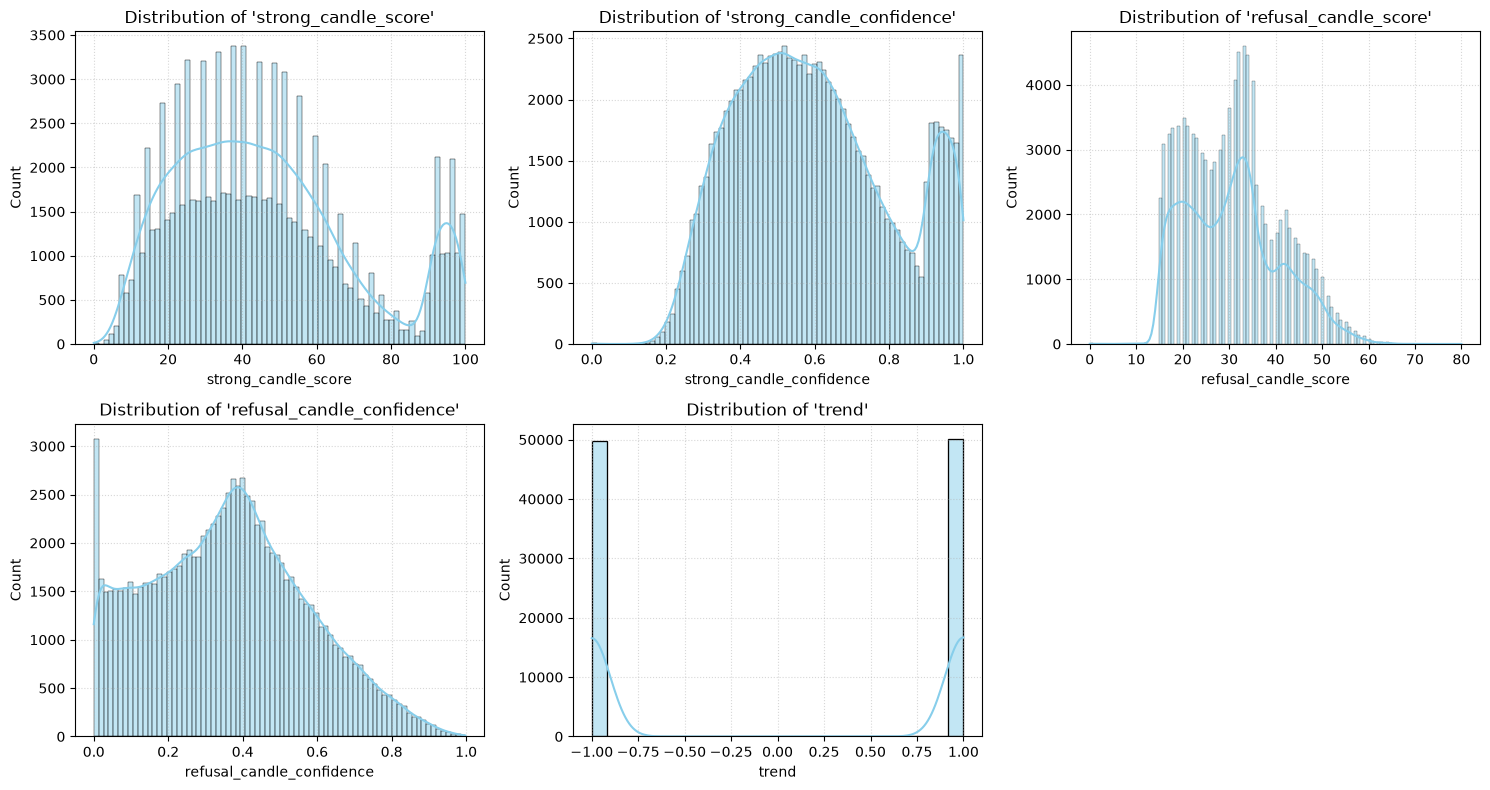

In [11]:
# Grab the processed dataframe
if not processed_symbols_data:
    print("No processed symbols data found. Make sure to run Section 2 first with a discovered symbol.")
else:
    active_symbol = list(processed_symbols_data.keys())[0]
    df_processed = processed_symbols_data[active_symbol]
    
    # Plot the distributions of core features
    show_feature_distributions(df_processed)

Highest quality 'refusal_candle' found at index 99924 with score 80 and confidence 0.87.


C:\Users\MHossein\AppData\Local\Temp\ipykernel_5272\4292199681.py:175: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Highest quality 'strong_candle' found at index 350 with score 100 and confidence 1.00.


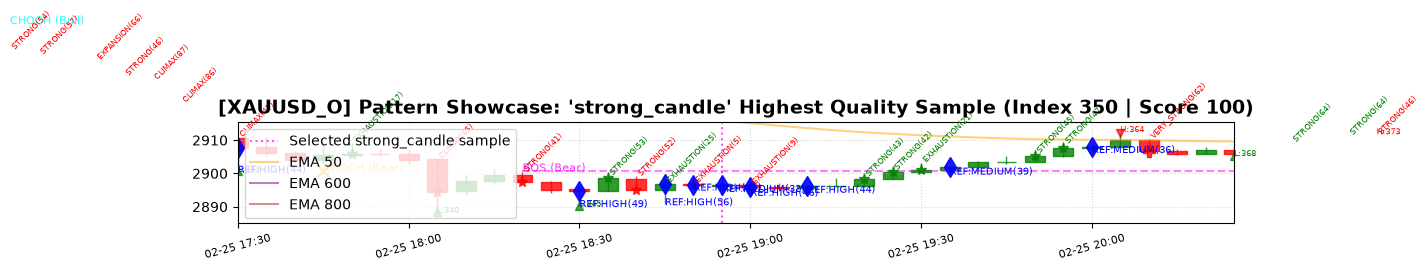

In [12]:
# Showcase the highest quality Refusal Candle and Strong Candle detections
if 'processed_symbols_data' in locals() and processed_symbols_data:
    active_symbol = list(processed_symbols_data.keys())[0]
    df_processed = processed_symbols_data[active_symbol]
    
    # 1. Refusal Candle Rejection
    visualize_feature_sample(df_processed, "refusal_candle", symbol=active_symbol, timeframe=TIMEFRAME, window_size=35)
    
    # 2. Strong Expansion Candle
    visualize_feature_sample(df_processed, "strong_candle", symbol=active_symbol, timeframe=TIMEFRAME, window_size=35)

Rendering BEARISH trend samples:
Discovered 2434 distinct continuous bearish trend segments.


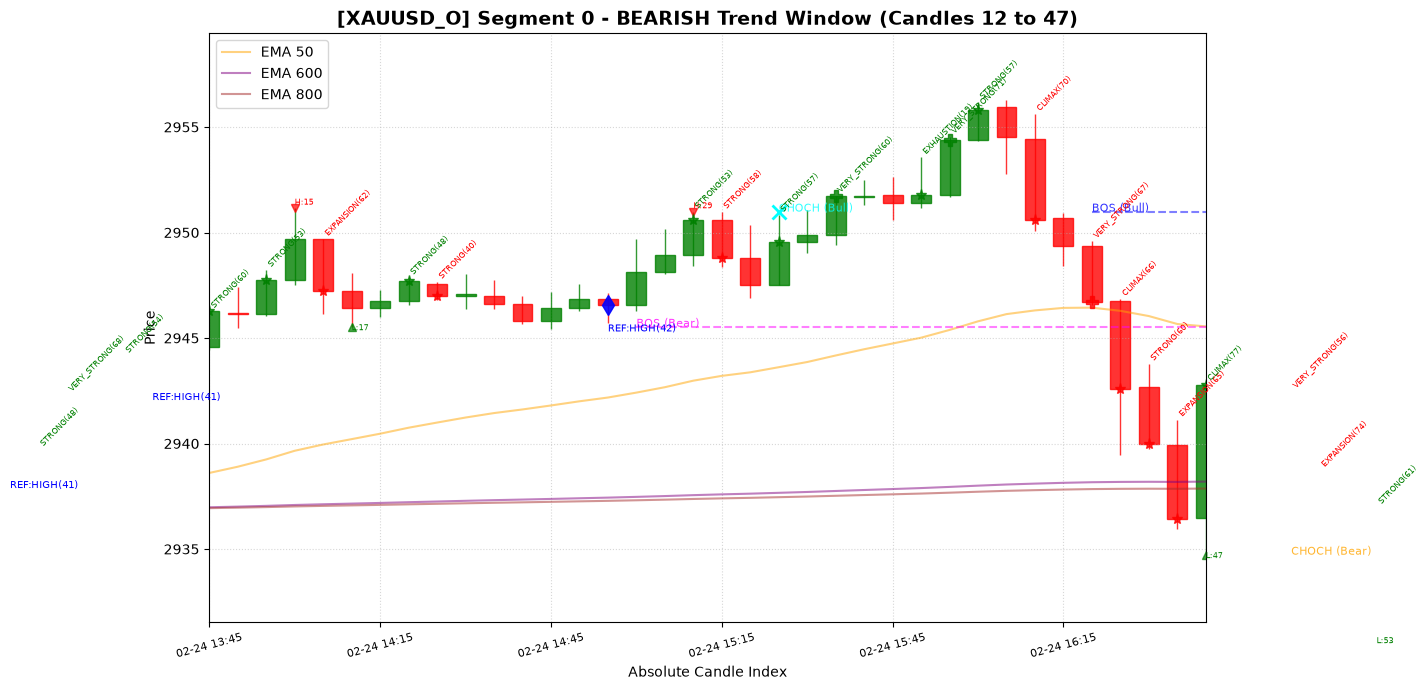

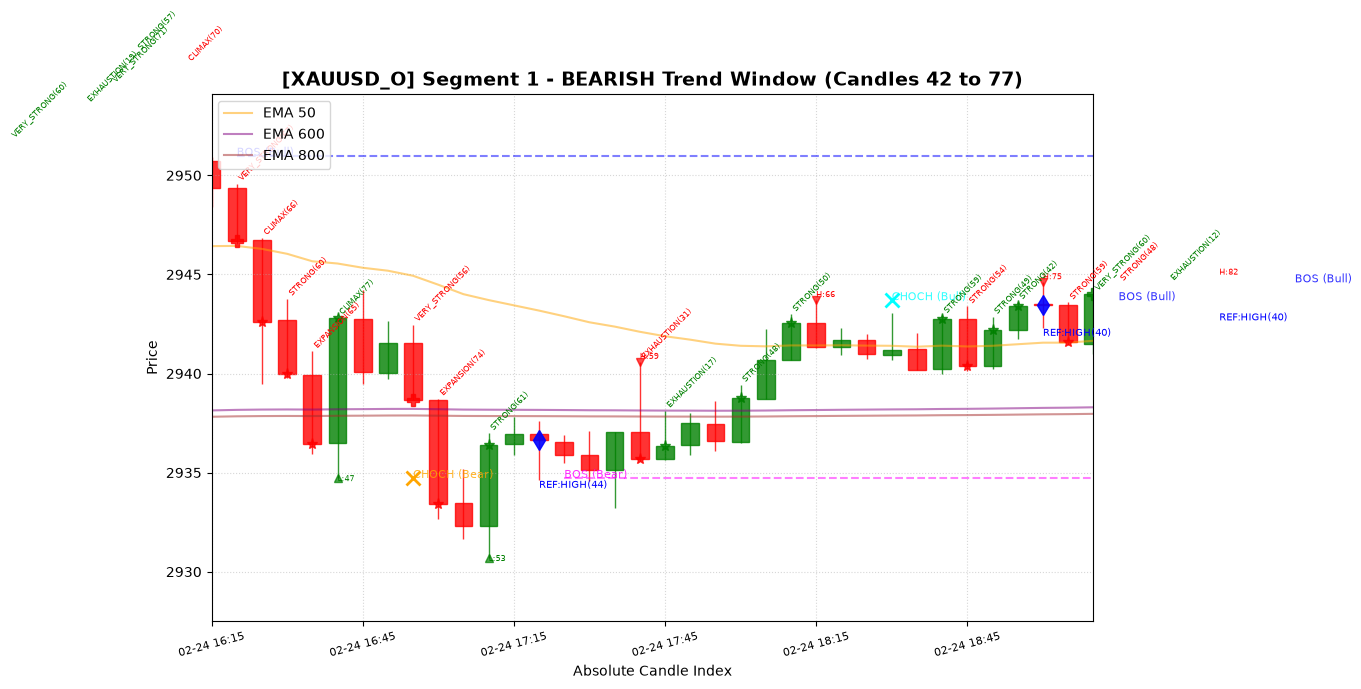

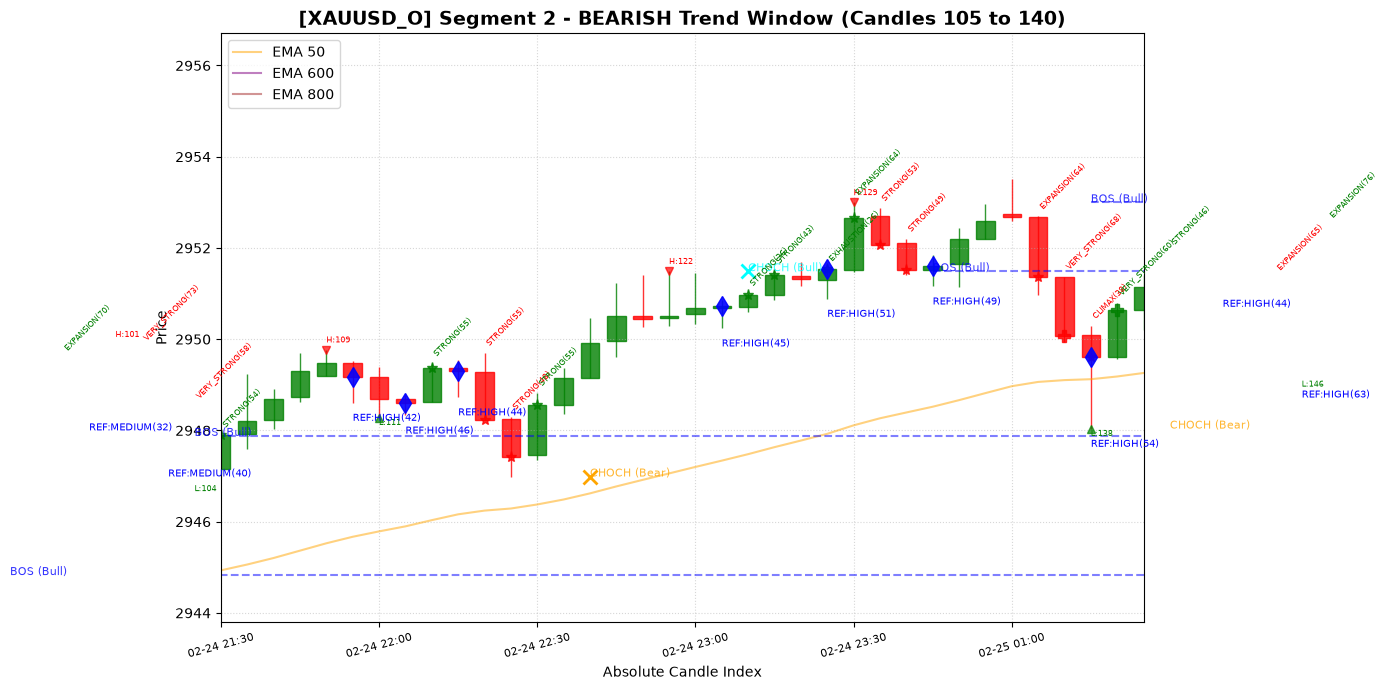

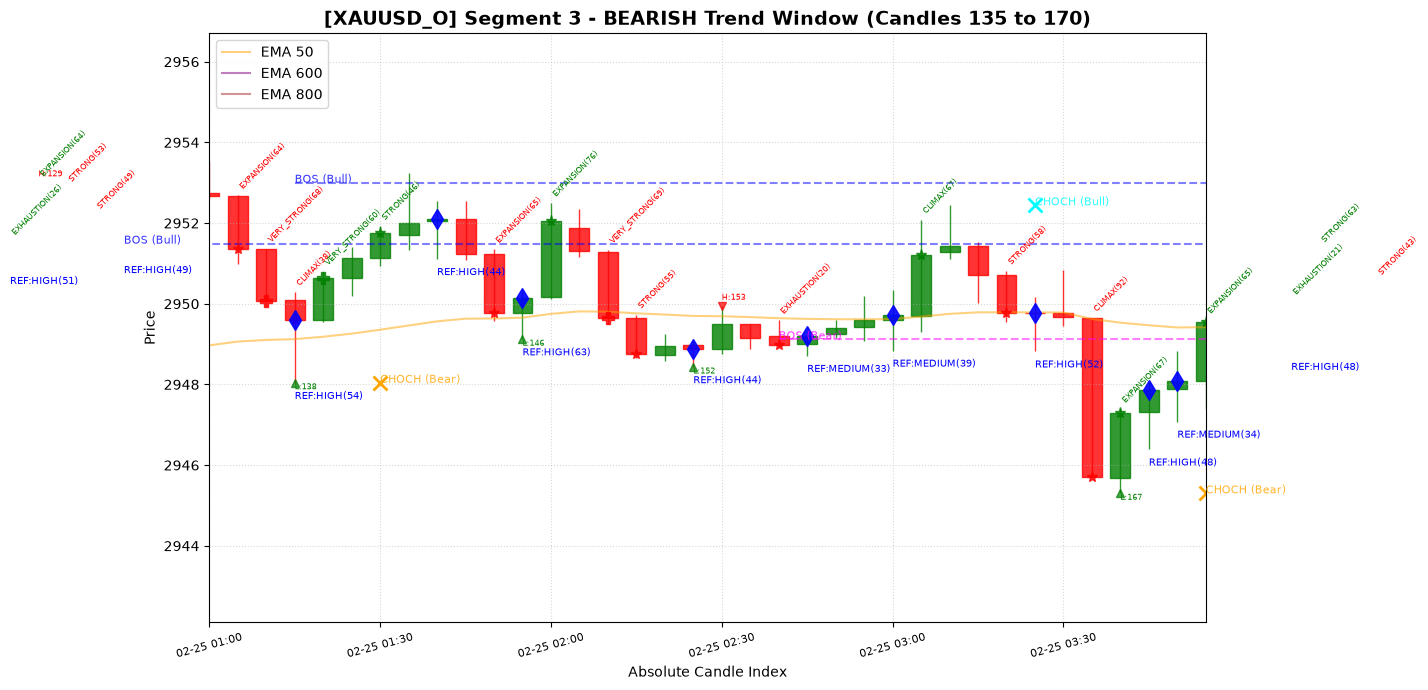

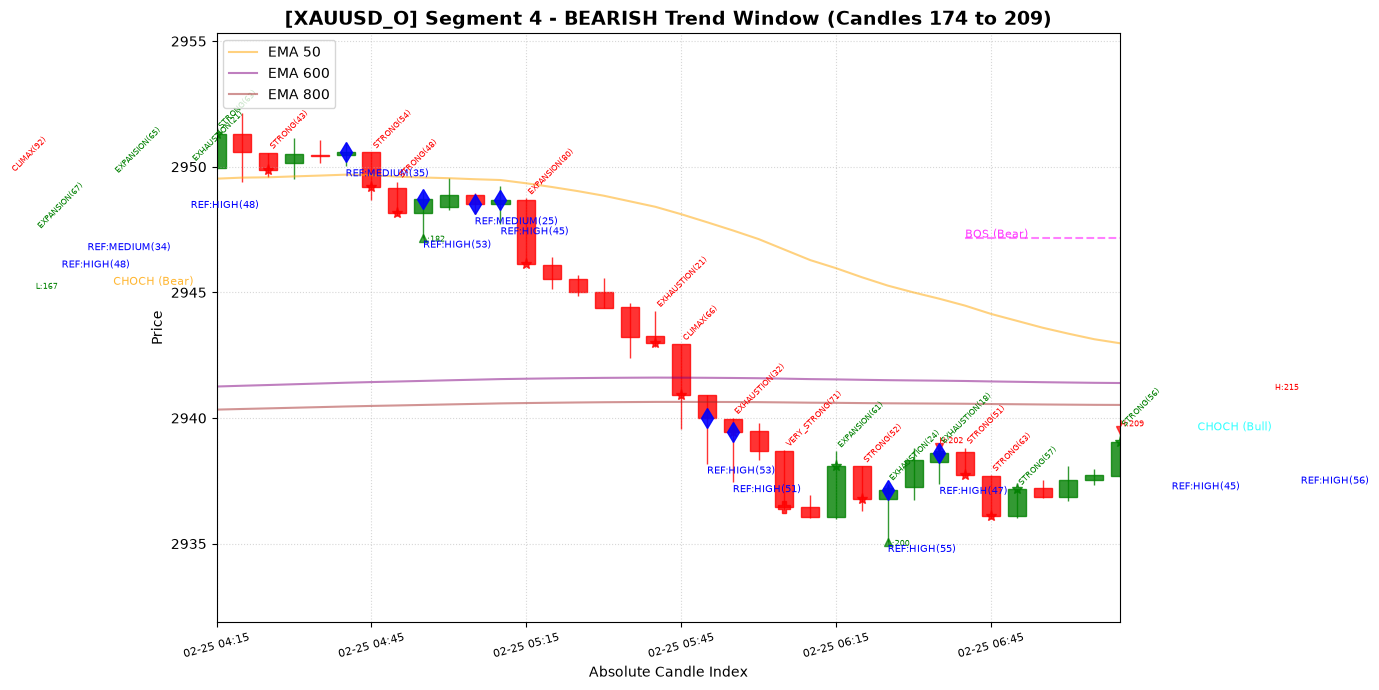

In [17]:
# Plot windows of matching trends (bullish, bearish, range)
if 'processed_symbols_data' in locals() and processed_symbols_data:
    active_symbol = list(processed_symbols_data.keys())[0]
    df_processed = processed_symbols_data[active_symbol]
    
    # Plot bearish windows
    print("Rendering BEARISH trend samples:")
    visualize_trend(df_processed, "bearish", symbol=active_symbol, timeframe=TIMEFRAME, num_charts=5)
    

Rendering RANGE trend samples:
Discovered 1 distinct continuous range trend segments.


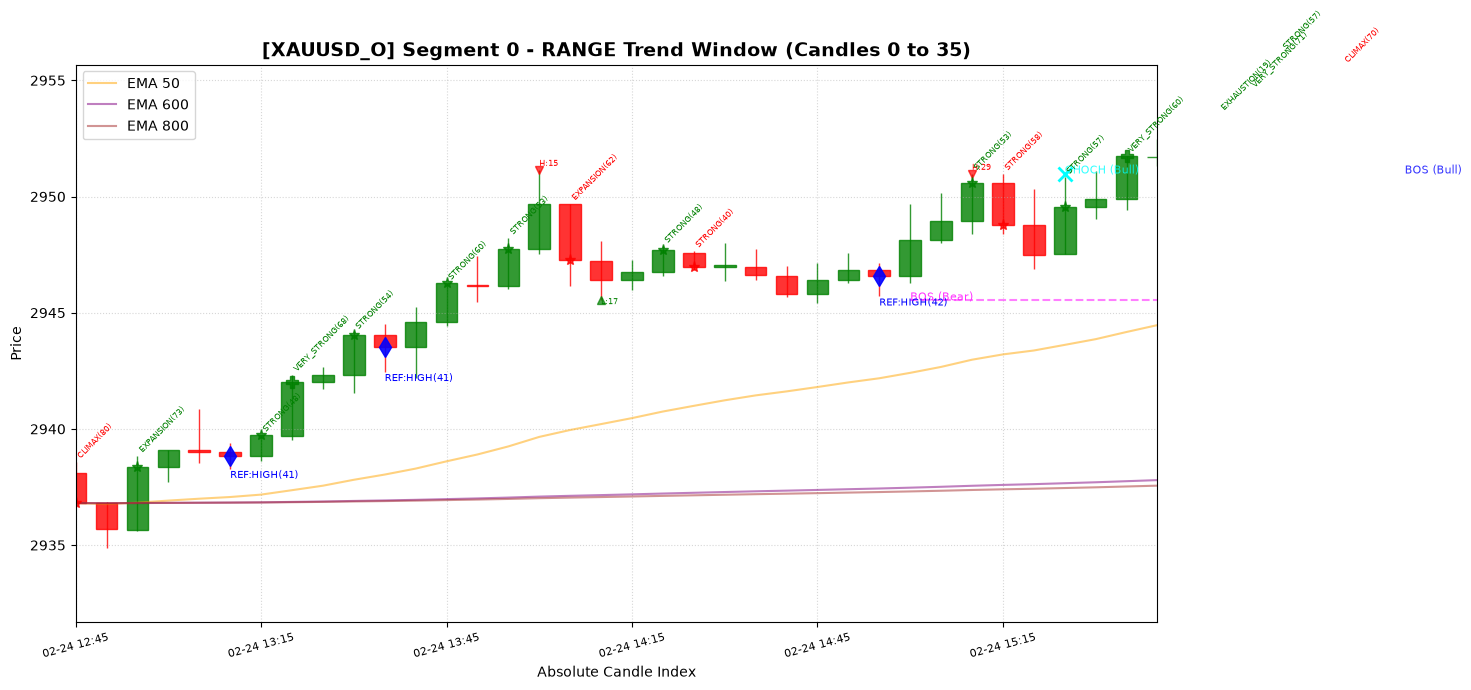

In [18]:
    # Plot range/neutral windows
    print("Rendering RANGE trend samples:")
    visualize_trend(df_processed, "range", symbol=active_symbol, timeframe=TIMEFRAME, num_charts=5)


Rendering bullish trend samples:
Discovered 2434 distinct continuous bullish trend segments.


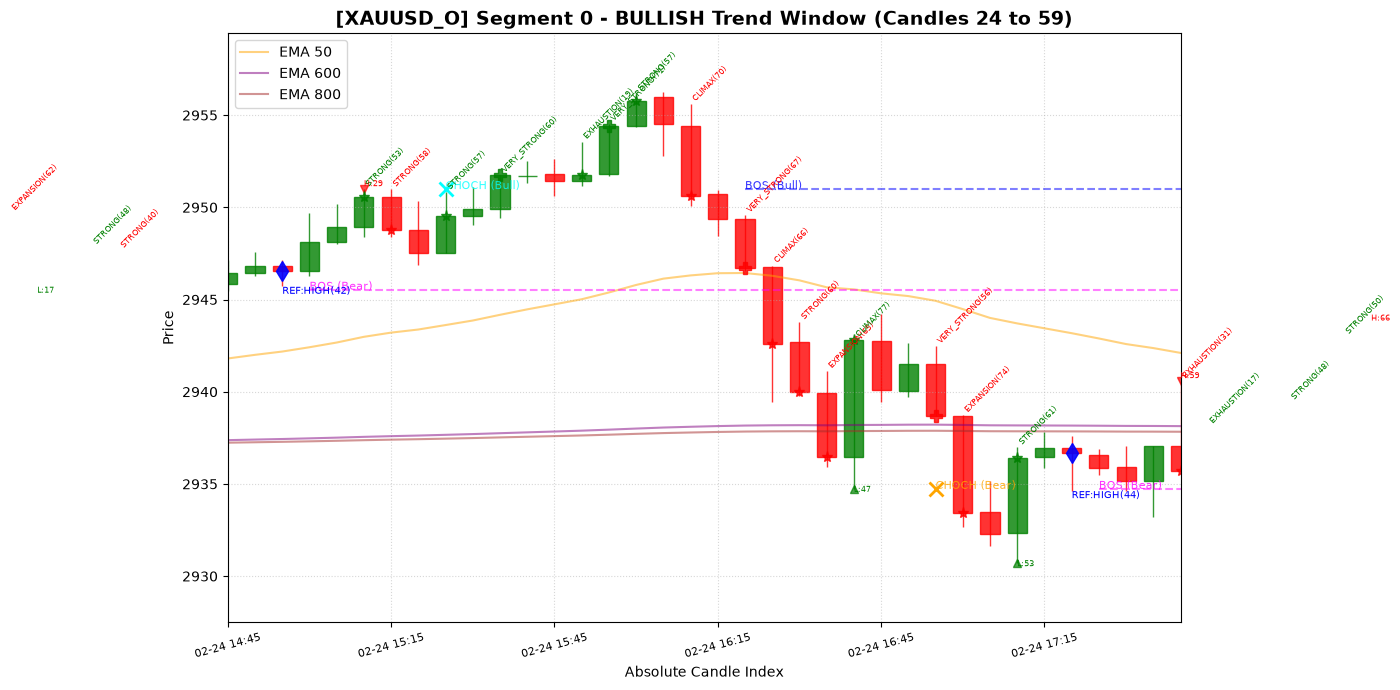

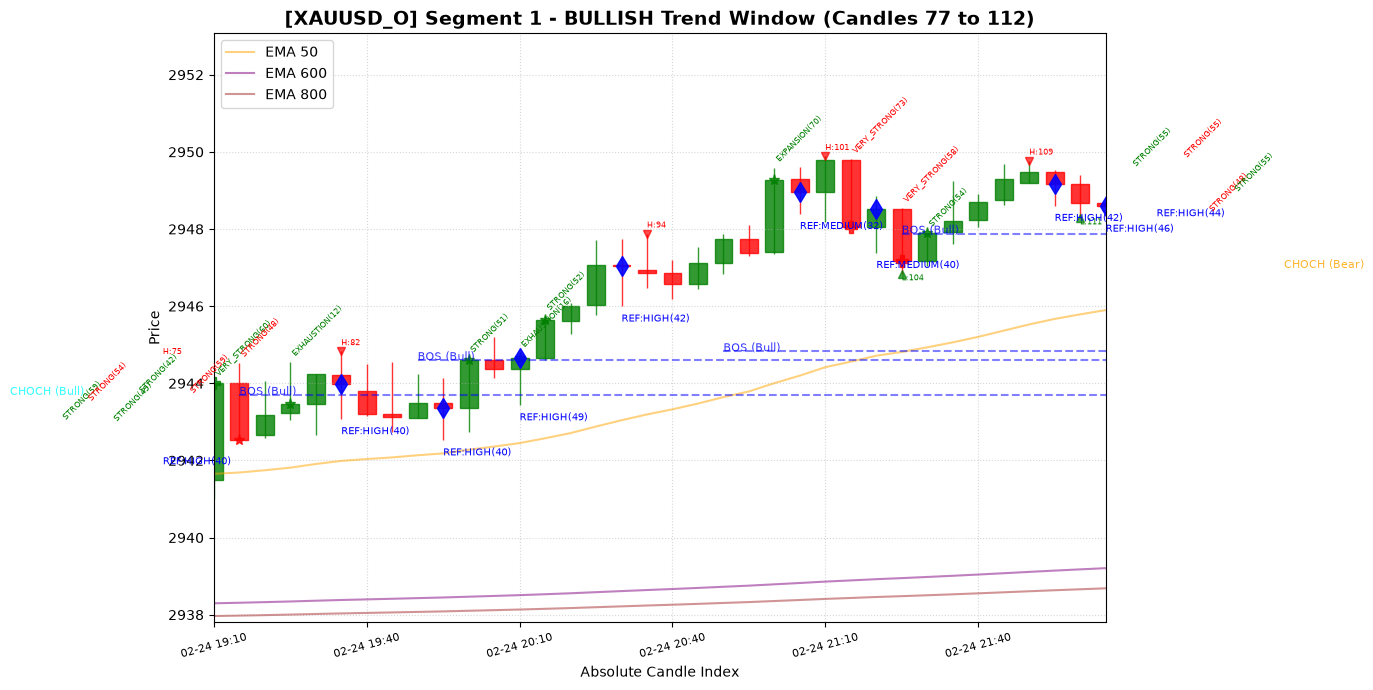

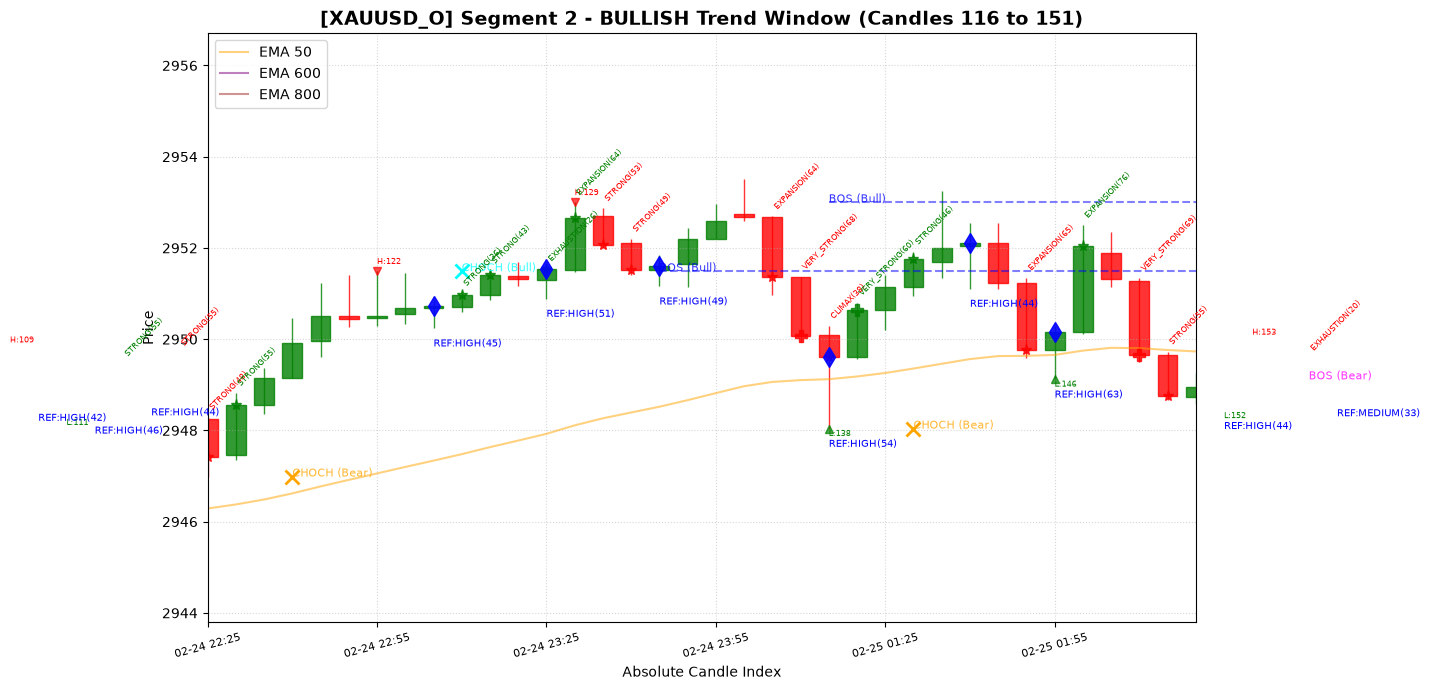

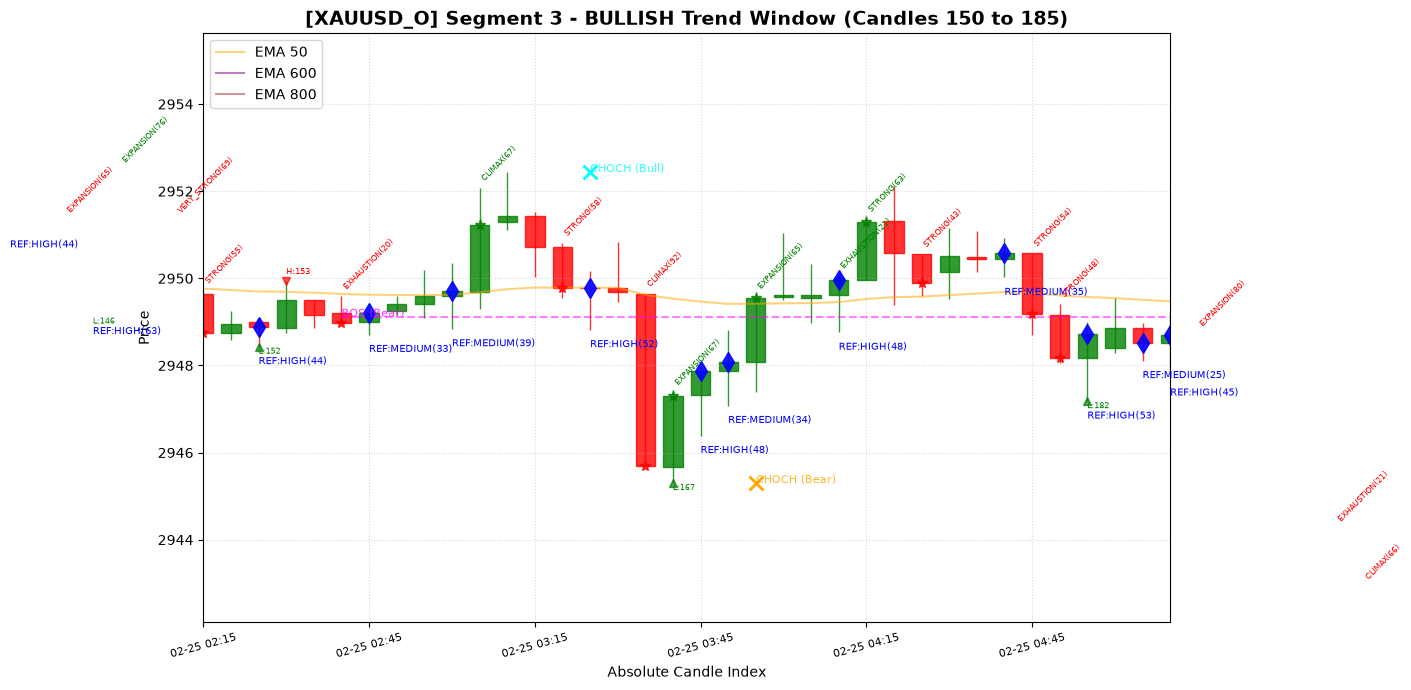

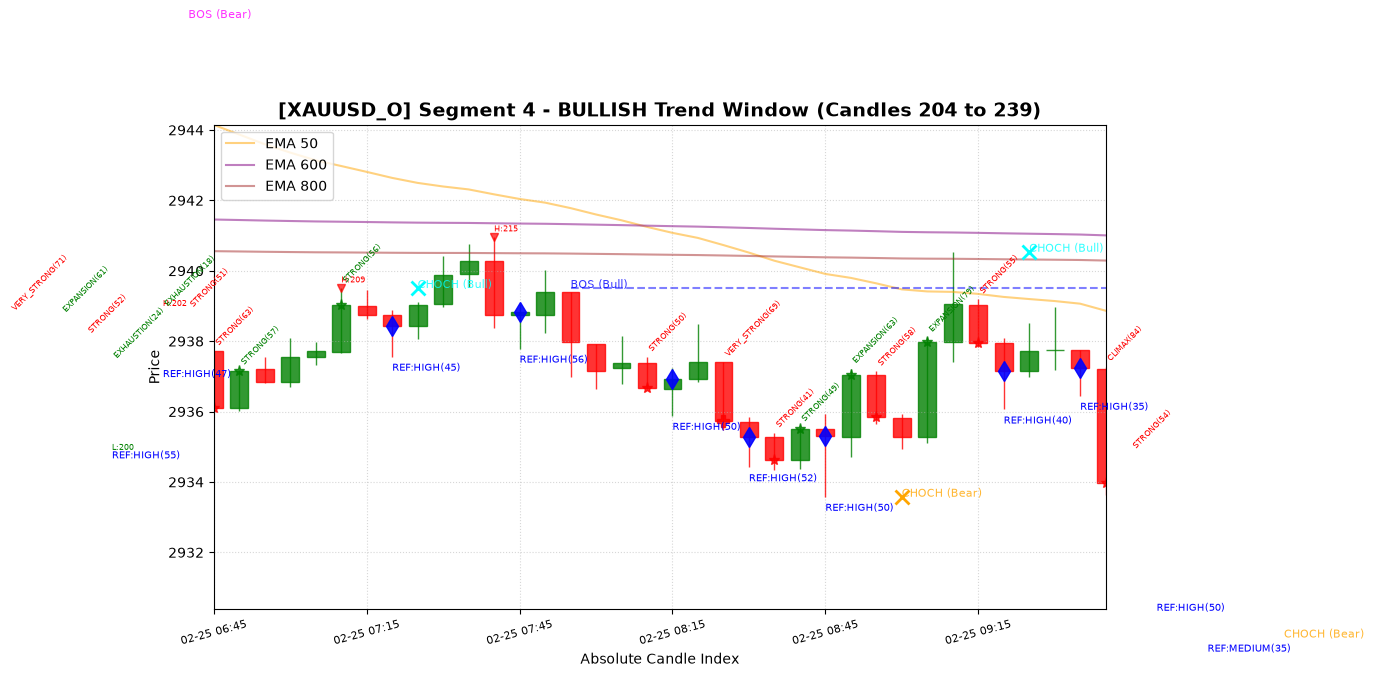

In [19]:

    # Plot bullish windows
    print("Rendering bullish trend samples:")
    visualize_trend(df_processed, "bullish", symbol=active_symbol, timeframe=TIMEFRAME, num_charts=5)